In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def random_color():
    return (np.random.random(), np.random.random(), np.random.random())

# Exploratory Data Analysis

In [2]:
path = "../../data/time_series_60.csv"
df = pd.read_csv(path)
df.head()

,utc_timestamp,AT_load_actual_entsoe_transparency,BE_load_actual_entsoe_transparency,BG_load_actual_entsoe_transparency,CH_load_actual_entsoe_transparency,CY_load_actual_entsoe_transparency,CZ_load_actual_entsoe_transparency,DE_load_actual_entsoe_transparency,DK_load_actual_entsoe_transparency,EE_load_actual_entsoe_transparency,...,NL_load_actual_entsoe_transparency,NO_load_actual_entsoe_transparency,PL_load_actual_entsoe_transparency,PT_load_actual_entsoe_transparency,RO_load_actual_entsoe_transparency,RS_load_actual_entsoe_transparency,SE_load_actual_entsoe_transparency,SI_load_actual_entsoe_transparency,SK_load_actual_entsoe_transparency,UA_load_actual_entsoe_transparency
0,2014-12-31T23:00:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,5946.0,9484.0,NaN,NaN,NaN,NaN,41151.0,NaN,NaN,...,9401.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,5726.0,9152.0,4585.0,7640.14,NaN,5957.57,40135.0,3100.02,764.7,...,8957.0,15104.99,13979.46,5123.9,NaN,NaN,14485.0,1045.47,2728.0,NaN
3,2015-01-01T02:00:00Z,5347.0,8799.0,4440.0,7391.44,NaN,5878.87,39106.0,2980.39,749.8,...,8462.0,14882.56,13453.78,4771.1,NaN,NaN,14298.0,1004.79,2626.0,NaN
4,2015-01-01T03:00:00Z,5249.0,8567.0,4418.0,7332.57,NaN,5827.80,38765.0,2933.49,746.5,...,8156.0,14755.09,13306.00,4443.5,NaN,NaN,14249.0,983.79,2618.0,NaN


# Filter only German load

In [3]:
filtered_cols = ['utc_timestamp', 'DE_load_actual_entsoe_transparency']

df = df[filtered_cols]
df.tail()

,utc_timestamp,DE_load_actual_entsoe_transparency
50396,2020-09-30T19:00:00Z,57559.0
50397,2020-09-30T20:00:00Z,54108.0
50398,2020-09-30T21:00:00Z,49845.0
50399,2020-09-30T22:00:00Z,46886.0
50400,2020-09-30T23:00:00Z,45461.0


# Dataframe statistics

In [4]:
df.describe()

,DE_load_actual_entsoe_transparency
count,50400.000000
mean,55492.468552
std,10015.431042
min,31307.000000
25%,47106.000000
50%,55092.000000
75%,64309.250000
max,77549.000000


In [5]:
df.shape

(50401, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50401 entries, 0 to 50400
Data columns (total 2 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   utc_timestamp                       50401 non-null  object 
 1   DE_load_actual_entsoe_transparency  50400 non-null  float64
dtypes: float64(1), object(1)
memory usage: 787.6+ KB


# Check for missing / NaN values

In [7]:
df.isna().sum()

utc_timestamp                         0
DE_load_actual_entsoe_transparency    1
dtype: int64

# Set timestamp index

In [8]:
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"], utc=True)
df = df.set_index("utc_timestamp")
df.head()

,DE_load_actual_entsoe_transparency
utc_timestamp,
2014-12-31 23:00:00+00:00,NaN
2015-01-01 00:00:00+00:00,41151.0
2015-01-01 01:00:00+00:00,40135.0
2015-01-01 02:00:00+00:00,39106.0
2015-01-01 03:00:00+00:00,38765.0


# Load histogram

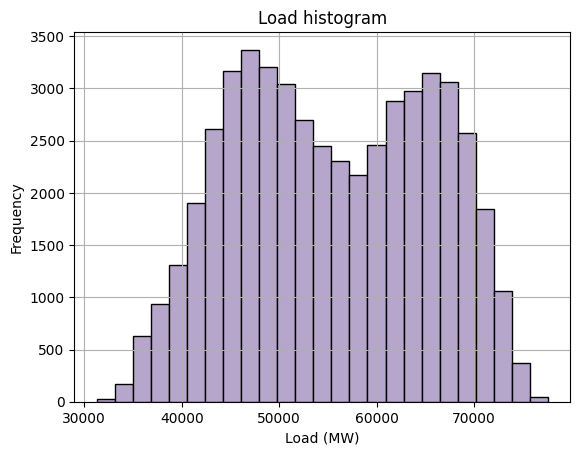

In [9]:
df["DE_load_actual_entsoe_transparency"].hist(bins=25, edgecolor="black", color=random_color())
plt.xlabel("Load (MW)")
plt.ylabel("Frequency")
plt.title("Load histogram")
plt.show()

# Load boxplot

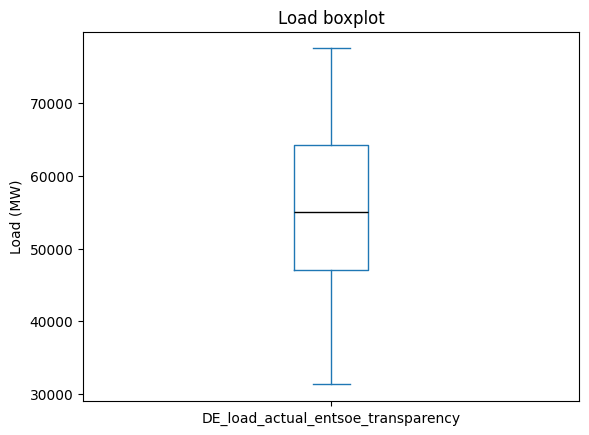

In [10]:
df["DE_load_actual_entsoe_transparency"].plot(kind='box', medianprops=dict(color="black"))
plt.ylabel("Load (MW)")
plt.title("Load boxplot")
plt.show()
plt.show()

# Plotting daily, weekly, monthly and yearly loads

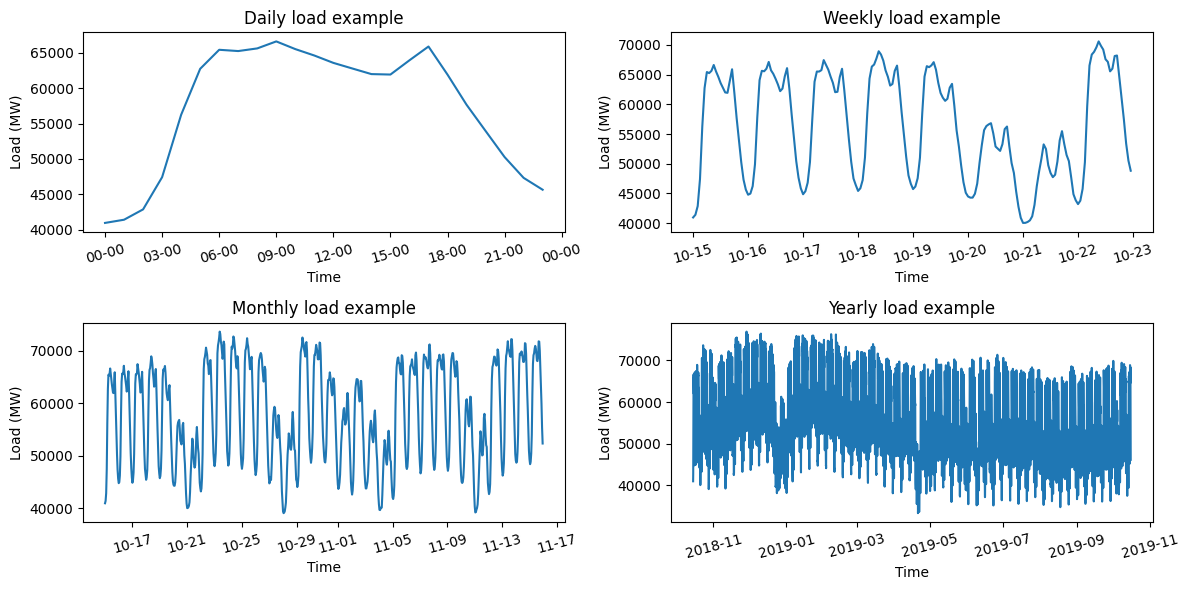

In [11]:
load_series = df["DE_load_actual_entsoe_transparency"]

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 6))
ax = ax.flatten()

date_ranges = [
                ('2018-10-15', '2018-10-15', 'Daily load example', '%H-%M'),
                ('2018-10-15', '2018-10-22', 'Weekly load example', '%m-%d'),
                ('2018-10-15', '2018-11-15', 'Monthly load example', '%m-%d'),
                ('2018-10-15', '2019-10-15', 'Yearly load example', '%Y-%m')
               ]

for idx, (start, end, title, format) in enumerate(date_ranges):
    subset = load_series.loc[start:end]
    ax[idx].plot(subset.index, subset)
    ax[idx].set_title(title)
    ax[idx].set_xlabel("Time")
    ax[idx].set_ylabel("Load (MW)")
    ax[idx].xaxis.set_major_locator(mdates.AutoDateLocator())
    ax[idx].tick_params(axis='x', labelrotation=15)

    ax[idx].xaxis.set_major_formatter(mdates.DateFormatter(format))

plt.tight_layout()
plt.show()

# Plotting smoothed yearly load

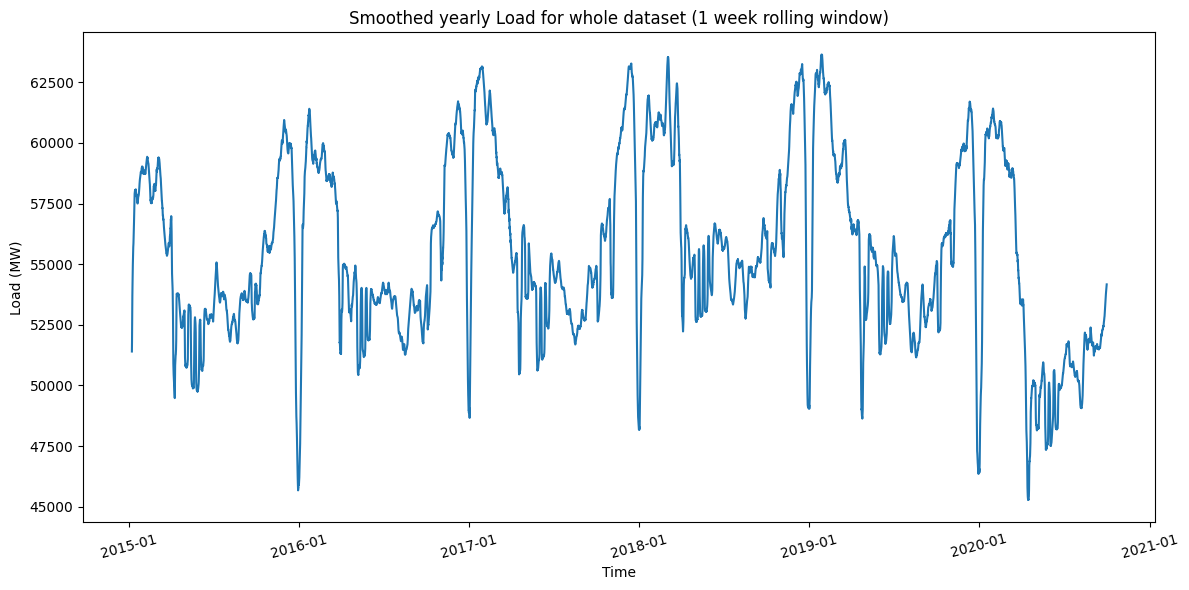

In [12]:
rolling_series = df["DE_load_actual_entsoe_transparency"].rolling(window=168).mean()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df.index, rolling_series)
ax.set_title("Smoothed yearly Load for whole dataset (1 week rolling window)")
ax.set_xlabel("Time")
ax.set_ylabel("Load (MW)")
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.tick_params(axis='x', labelrotation=15)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

# Short summary

- load data is fairly regular, only one missing value (first value NaN)

- load distribution is bimodal with peaks around 45000 and 65000 MW

- no outliers

- load demonstrates cyclic behaviour on weekly, monthly and yearly bases with sharpest drops around January every year (holidays, less power consumption)